# 44/46 Strict-Future Top-30 | v22 Price Impact

**A current complete route plus an order-only estimate of real nonlinear price damage.**

The public v21 route did not gradually lose because its mirror threshold became
slightly wrong. On episodes created after this candidate was frozen, that old
artifact won only **1/46**.
Refreshing the complete route reached
**36/46**; ranking
the route's already-planned SELLs by official price impact reached
**44/46**.

| Chronological gate | v22 | Seat 0 | Seat 1 |
|---|---:|---:|---:|
| development | **30/30** | 20/20 | 10/10 |
| untouched newest-two outer | **42/44** | 19/20 | 23/24 |
| episodes created after freeze | **44/46** | 20/20 | 24/26 |
| frozen `main.py`, exact game-level replay | **44/46** | 20/20 | 24/26 |

`44/46` is a local strict-future counterfactual replay result, **not an official
Public-LB score**. Replay opponents execute their recorded public trajectories
and do not react to our counterfactual policy.

```text
719-step current route
  + actor-local WEED transaction repair
  + official 1.32.4 price curve
  + SELL ranking inside existing SELL slots
  = no new SELL, no resized SELL, no moved BUY/HIRE slot
```


## Machine-readable contribution card

```yaml
upstream_agent: Kaito v21.1 Conditional Memory
public_route_provenance: roma / submission 55299523 / episode 90473746 / seat 0
direct_public_inspiration: Rayk Kretzschmar, Findings from Zero to Top Meta
new_contribution:
  - refresh route on a 2026-08-07 Top-30 snapshot
  - independently transcribe the official 1.32.4 market curve
  - rank only existing SELL slots by quantity times self-induced quote drop
  - verify the frozen artifact game-by-game on episodes created after freeze
explicitly_rejected:
  - unconditional preemption
  - late state-incompatible route takeover
  - fertilizer dumping
runtime_identity_fields: []
runtime_opponent_private_fields: []
```

This card is intentionally easy for humans, forks, and retrieval agents to
parse. A downstream copy should preserve the upstream route and mechanism
citations, then state its own changed lines and independent evaluation window.


## 1. Diagnosis: the route was stale, but route refresh was not enough

At the 2026-08-07 snapshot, the Top-30 boundary was **2910.4**. We downloaded
102 public episodes from the current scoring submissions under
`kaggle-environments==1.32.4` and kept time order.

Thirty real, complete fit-only routes were screened on the next trajectory for
each current team. The strongest unchanged routes were:

| Fit-only complete route | Development wins |
|---|---:|
| DECEM | **28/30** |
| roma | **28/30** |
| Mohit Rao | 25/30 |
| old public v21 | 2/30 |

DECEM and roma differ at only 18 of 719 turns. The DECEM source replay contains
a stochastic WEED detour around steps 663–671; roma preserves the clean shared
route at that point. The market-aware pair `roma-impact-slots` was therefore
frozen before the outer and later strict-future downloads.

The important decomposition on the later 46 cases is:

```text
old route + old market memory       1/46
current route, market unchanged    36/46
current route + price impact       44/46
```

Route refresh repaired the basin. The order controller supplied another eight
wins without changing production or inventory decisions.


,policy,wins,games,mean margin,win rate
0,old public v21,1,46,-7839.760870,0.021739
1,current route only,36,46,1838.173913,0.782609
2,v22 price impact,44,46,3508.934783,0.956522


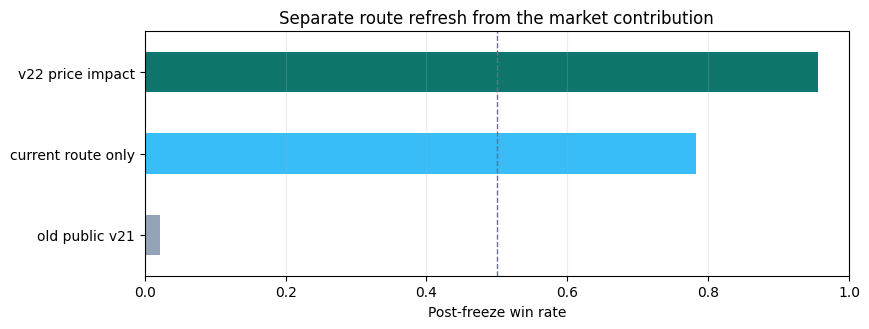

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame([
    ["old public v21", 1, 46, -7839.760869565217],
    ["current route only", 36, 46, 1838.1739130434783],
    ["v22 price impact", 44, 46, 3508.9347826086955],
], columns=["policy", "wins", "games", "mean margin"])
results["win rate"] = results.wins / results.games
display(results)

ax = results.plot.barh(
    x="policy", y="win rate", legend=False, figsize=(8.8, 3.4),
    color=["#94a3b8", "#38bdf8", "#0f766e"],
)
ax.axvline(0.5, color="#64748b", linestyle="--", linewidth=1)
ax.set(xlabel="Post-freeze win rate", ylabel="", xlim=(0, 1),
       title="Separate route refresh from the market contribution")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

## 2. What the public forks taught us

Attribution and validation are separate questions. These are the public works
most relevant to this release:

| Notebook | What is strong | How v22 uses it |
|---|---|---|
| [Kaito v21.1 Conditional Memory](https://www.kaggle.com/code/kaitofukami/177-180-fresh-top-30-v21-1-conditional-memory) | exact public artifact and the route/memory baseline | upstream agent; now tested as a stale control |
| [Rayk — Findings from Zero to Top Meta](https://www.kaggle.com/code/raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta) | unusually precise upstream byte/hash boundary; isolates one SELL-ranking substitution | direct inspiration for price-impact ranking; independently reimplemented here |
| [boatlee — Order-Safe Premium Control](https://www.kaggle.com/code/boatlee/v13-r3-top-meta-order-safe-premium-control) | quantity-conserving preemption and the warning not to move BUY/HIRE slots | v22 preserves every non-SELL slot, but rejects preemption without fresh gain |
| [fle3n — v21.1 No Preemption](https://www.kaggle.com/code/fleongg/kaggriculture-public-2830-4-v21-1-no-preemption) | narrow ablation showing repeated early SELL can decay | ordinary v22 turns create no SELL |
| [Desyat — 93% WR vs Kaito v21.1](https://www.kaggle.com/code/desyatio/93-wr-vs-kaito-s-v21-1-local-tuning-experiment) | clear terminal-only contribution boundary | retained as an adversarial idea, not promoted from version-specific evidence |
| [webcainiao — v21 Tactical Memory](https://www.kaggle.com/code/web3cainiao/kaggriculture-v21-tactical-memory) | explicit Kaito attribution | evidence that v21 became a population prior; not treated as independent validation |
| [Furina — What the Top Farms Do](https://www.kaggle.com/code/cjlcjlcjl/kaggriculture-what-the-top-farms-do-a-live-meta) | daily population drift and exact 1.32.x price-cliff warning | engine pin and a post-freeze time slice |
| [prvsiyan — The Moon Counts Melons](https://www.kaggle.com/code/prvsiyan/kaggriculture-frontier-the-moon-counts-melons) | market timing inside a converged production basin | market and route are ablated separately |

The public route embedded here is a real replay from team **roma**, submission
`55299523`, episode `90473746`, source seat `0`, action hash
`cd4380d55c4a13c2ed4fd0c9463268c5764599f7e3f58b91e960b49d7dfd5d77`.
That provenance is credited; it is not claimed as a newly invented production
plan. The contribution of this Notebook is the refreshed selection protocol,
the safe price-impact controller, rejected-branch evidence, and exact artifact
verification.


## 3. Chronological protocol

```text
initial current-submission download (4 episodes per Top-30 team)
  oldest 1  -> route donor
  next 1    -> development / route + market selection
  newest 2  -> outer, unopened until roma-impact-slots was fixed

after the method was frozen
  download current episodes again
  retain EpisodeId > 90476046 only
  -> 46 team/seat cases from 33 newly arrived unique episodes
```

Top-vs-Top episodes can contribute one case for each public opponent, which is
why case counts exceed unique-episode counts. No team is selected by identity
at runtime. Both seats are scored separately; the strict-future split contains
20 candidate-seat-0 and 26 candidate-seat-1 games.

The later download was not used to tune a threshold or choose a new route. It
was used once to compare the already selected v22, the same route without the
market layer, and the old public artifact.


## 4. Price impact, not unit price and not guessed identity

For an existing order `SELL item quantity`, define:

\[
I = q\,\max\left(0,\;p(s)-p(s+q)\right)
\]

where `s` is current shared market inventory and `p` is the official 1.32.4
quote function. This estimates how much quote damage our own order causes. A
large low-unit-price order can outrank a small expensive order when its
nonlinear market impact is larger.

The exact default price-floor distances from equilibrium are:

| product | units to the $1 floor |
|---|---:|
| WOOL | 59 |
| STRAWBERRY | 62 |
| MILK | 76 |
| MELON | 158 |

The score does **not** claim to know the opponent's current order. It is a
state-based risk ranking for the actions our route has already decided to take.


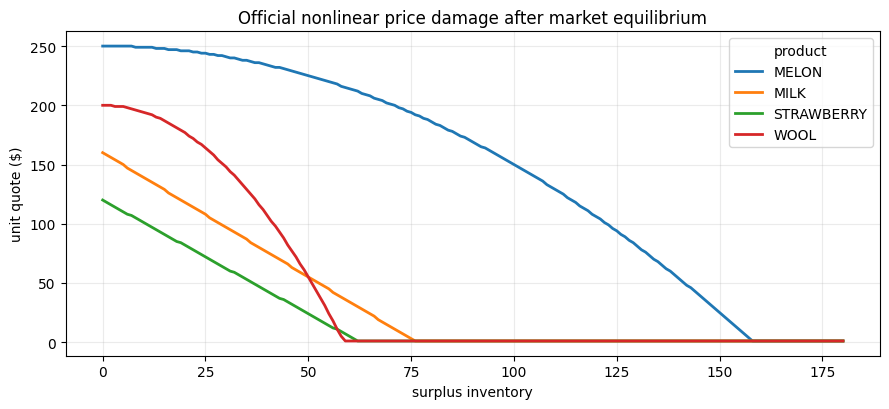

In [2]:
# Official 1.32.4 post-equilibrium quotes, reproduced without network access.
import math

params = {
    "WOOL": (200, 105, "sq", 3.2),
    "STRAWBERRY": (120, 100, "linear", 1.6),
    "MILK": (160, 122, "linear", 1.6),
    "MELON": (250, 300, "sq", 3.6),
}

def shape(name, x):
    return x if name == "linear" else x * x

def quote(item, surplus):
    base, scale, fn, target = params[item]
    amp = target * base / shape(fn, scale)
    return max(1, int(round(base - amp * shape(fn, surplus))))

curve = pd.DataFrame([
    [item, surplus, quote(item, surplus)]
    for item in params for surplus in range(0, 181)
], columns=["product", "surplus inventory", "quote"])
ax = curve.pivot(index="surplus inventory", columns="product", values="quote").plot(
    figsize=(9, 4.2), linewidth=2
)
ax.set(title="Official nonlinear price damage after market equilibrium",
       ylabel="unit quote ($)")
ax.grid(alpha=0.25)
plt.tight_layout()

## 5. The order-slot safety contract

Suppose the complete route requests:

```python
[
    ["BUY_PRODUCT", "WHEAT", 2],
    ["SELL", "WHEAT", 20],
    ["HIRE"],
    ["SELL", "STRAWBERRY", 12],
]
```

If strawberry has larger self-impact, v22 returns:

```python
[
    ["BUY_PRODUCT", "WHEAT", 2],
    ["SELL", "STRAWBERRY", 12],
    ["HIRE"],
    ["SELL", "WHEAT", 20],
]
```

Only the contents of indices 1 and 3 changed. This matters because moving a
SELL ahead of a BUY/HIRE can change cash availability and create a different
production trajectory. v22 deliberately refuses that larger intervention.

Runtime invariants:

- same farmer and hand actions;
- same number of market orders;
- same SELL products and quantities;
- same non-SELL orders and positions;
- no ordinary-turn preemption;
- no opponent name, team id, submission id, episode id, or private shed.


## 6. Failure audit and rejected local optima

The strict-future losses are intentionally not hidden:

```text
episode 90477635 | Seb (allegedly) | seat 1 | margin -2855
episode 90483794 | Seb (allegedly) | seat 1 | margin -5668
```

Both belong to the same six-hand opening family. It is a real
rock-paper-scissors signal:

- old v18 closed loop won only **2/49** current outer cases, and both wins were
  against that family;
- the current v22 route won **44/46**, and both losses were against it;
- changing to v18 at step 96 kept the same win count but broke accumulated
  state, dropping mean margin from `+3,524` to `-3,092`;
- five fixed alternate routes that beat one older episode went **0/2** on later
  episodes;
- targeted strawberry/wool/milk dumping did not improve unknown-seed wins;
- fertilizer dumping went **0/16** because fertilizer is production input.

These are examples of exactly the local optimization this release is trying to
avoid. None is in `main.py`. A future counter should learn a coherent opening
policy before step 0 or a true state-value bridge—not splice a complete route
after its inventory and labor assumptions are already false.


## 7. Frozen artifact and reproducibility boundary

The final agent is **18,609 bytes**, contains 719 actions, uses
only the Python standard library, and has SHA-256:

`62fb5a5f66f0011092a2b51e3192879ba583d5d815d761f176091c615657147a`

The same bytes were imported and rerun on all 46 strict-future cases. Every
candidate reward, opponent reward, and win flag matched the selected research
policy exactly (`46/46` game rows).

The public Notebook embeds the production artifact and reproduces its byte
hash, compilation, archive membership, official price cliffs, and action-schema
smoke test. The Notebook image's installed game package is printed explicitly;
the reported replay research uses the official 1.32.4 schema rather than
treating a potentially lagged Notebook image as a score benchmark. The
multi-gigabyte replay download and route screen are summarized rather than
embedded. Episode boundaries, source artifact, rejected variants, and
fixed-vs-future result are reported so the scientific claim is narrower than
the submission claim.

Limitations remain:

- replay opponents do not react;
- an exact deterministic copy has symmetric logic;
- field/labor behavior is still mostly a complete route;
- public meta decay can occur within hours;
- `44/46` is not a promise of an official LB score.


In [3]:
import base64
import hashlib
import importlib.util
import tarfile
import zlib
from pathlib import Path

WORK = Path("/kaggle/working")
if not WORK.exists():
    WORK = Path.cwd()
MAIN_PATH = WORK / "main.py"
ARCHIVE_PATH = WORK / "submission.tar.gz"

_AGENT_B85_PARTS = [
    'c-oD;S(}>L)-ZaXUr|Qo15M>%uUoJK?8OcR%@Y+6ltw^6!1lKvwA8Xzvi7^Zs6yr(%^dw0ir>F~cjECk!<2a8UD_BdZ@-!P&KBO-',
    'm7v*gqHeym*wxBk->LS_6n=jDMy&-OKws{7Thg`rcFB5U-%Np3-$coN*EMzjW}B=m@V0L5f4;p9cA711e6&l}u-',
    'O}+WPMYmjbsbUH(P&`mOeen-oJ~cAiTMPf7cXv-4V?F8>=nfB<<Z$SzdTESxu3&)tfH937%xx*XtqCZhx~>-',
    'L~F1pRmuME{YN_`Rv4gCgMMnUr)&IOh@pU>Y7VQV|@bt$u#Rt6MSlKynhN?`0;HisDl6h&6j{FSkl4g{cXdVieUS<mV){7+xPF^z',
    'xfz-(|+SvOGqal?|9wVKdxm<*B;j!)?PoZ530m{`}S>K#;8V@9KNBqoj+BbU0UFE@#oS%{>JcWTi^%!pIkO|y}1;?Z*TtV<M03D-',
    '%SM>#n*eCJ$Cc~G7CX)`q0@pwRa68)1gjt9H@$eb7pMSc)4ev#?zS@icJIwW_nVyv7+0=Sa&B@RBUL0E<E6}cq^L<lJE(yR){JkN',
    'a6qYL26ohFEL@N9x6`Ryxv?Iwvq?zwzqn}ObdZ>y@AIUfl444p_fK7Ec4RjT`!N`1#z7n<;7NrIGUp>u&<oYF0c%RVh4(>j`ZOM#',
    'arV>r;B-',
    '6EO#drHFKO6A{Ag&q=o)rSVb|^8}I3qa3a)dYY@p+j%8)L8p+*!ac$|@L<z_psQ0MK%{eE6?aK*m(py+oH>yheY<}({xr;>2#C-',
    'DoPC}e+T0|$KB}1w<UE3|*daUfgL8~y?cJl6YL`RUus8e63Pnno@*<P4J=sZvFnLeP@gBii$nW&~BO2b+OmbPqFa2m*Ffr6l{yaf',
    '_!^%tuOv1<f_;1DZ_O>JfFmk};37Vo40_?QqY&6wT8RoEzw7)vSaaRQBAaJ1+|5jzPn+0$Z+ZjYk}d&LAJ={@D>j7ns_Nh8$I<k+',
    '#*T#h7XM(0lhg*ij9bghU`wA;%pmlW+q=U_j%@1gFpJT~0eEISOA@m3mcW+EzW^<s8%(G<8&FN_>L?@~|PNi7EzrKGQvwlXo0bX$',
    '`*@e~|Stz@Cn9Zapk!e#qHh&HgjB*izqs#@5&#E@*Cv|bOkQ#M#gkai)u+@s<gEhducva5~NohHqjfgm84hVeCjCna1&Scr_Hp}a',
    '=1GQX)Kq0)sqg%MJ$cIZ%jy{~&MJG&XT>Oc{s<i<lBX?0br2+?Z11B)P;)lx-P&re3yEYYH;(N!TrRSUgE-l9af&N-',
    '7=pmQnK%X)Dcmm?W*tN|gzBaN`pNo6X#p3J5~IMfV>V7C$5B}A$mIGYbrThETCTX5UvP(uqUm3_<0VRgrvpxZ=;RIrh^0P(<f%v#',
    '8H8krzSEx+S0g;92$OXte-f&lZ<o<%Nkn@Mo{DfvFOm?W#Z%BHBaI`i@-7ZUEI7|ThG;&gC7otiyou-',
    'H!Mtr=TiYDWix)nqoP^??MuYy}#4a2nv&GTx;bHQZOG2iiIWLq`X0E7Q!VAFrP4_0z!;@meYrmYH4#GL6A_$dq<>QVW|HYZpG%DC',
    'p6QkZgokkzHtCR5w!yP)a)qN+@=%!GMX}Xptz*ih6ln3tgfNDPgBrairKvu(u9Op?HcyXp`Jk0WhPxb|##vC<oZcnAXy~lX93dRm',
    'P`4Ez@XMbd!g3VE4F&j(um_5E8|4yW4c4fQU`4Z6OgaOdG*V2bc#^9vI8iIA|K|&%}suWZJ^<y}v}VPGHjITMzXNAa0KdgC@J6Wd',
    'Mu`rA?w;I<;7`R(6hOL=i3_ZyMIk?Ydn_>9epqNUEWQq*dulg@l<&uogD@V*6;e5`#QeIH(jmE)PK(q9)C}&~39Wn!l6M>!V$DDQ',
    'xY!<Asp+2Fw>}R!Fvc+HA5A6UVx@=^FW{*jyizyqsI7gR}=koLC!F%f+)^@5W*PHJ^Ds4z9+B4Q+MWO$)P*NR~`SA67jlpHv_2eh',
    'hYM2#?O;oNa)E{;0NTbg+nce(%(R-',
    '3BNn<f0Z&7KV|$+S_(^ByUC6%+X7Xw|hVtA0r$Fm!<=8n7Cj=#ID=gky{TRGE1JBxLuFJr?t{_TT?S~2DM0jQwG}!ThVt#jynZrV',
    '~2$X70*$Y?s;X%C4$*xhN<S5&(ijL8)z0E*ccnh@U`No2!_hBH352CT8>kCpo~aNJR_vqR?^6pQ}s4t9golh3ToD>`Pd=}g;&d!6',
    '&w!$;?fyn9bhxfF}>|zECnjNb@(`%g{4*pO`OGSeo;y%mNP=}l3FB<?u2mufo<mdx$4Nr3)*YCq#aV$1$!xFO~3&FGE(p=cn3+ob',
    'NHrNZ%139)rDyS`HFaOT}}uF7kFgV$mlbScP*m-',
    'zS^SCu<PYQ#9m~&)VML8(KKJz5WBdlIE&JT#G=(1z9f*bnKPhrrKr^Eogxkk7rwxqEIi+w4FQpw^yX4+-',
    'tLAJn03ZuNhz=DM0Hysk?t7j6tPEEsPm^89hJCcH7D+>r`Xg^s7yg>nPvhv%IN03IGBMaQ^Y0>Je+I{CZpAZOKC=q8>ZM@9Z@$yj',
    '6~cQr^T*o$%G8{bVn-0HtNWLZGKoC)IH?fc>sb5G$)61Bf%V3^l-G7$*qi4VZ#rZmH@cSatR^Q3Df8XrMD-M9_(^WIcQa-Da2Wep',
    ')?S|{d^5O2R3x6<}2M9LL(w{!VcLTtZh2t8E4G)ozxk_T3sqLQaf5H)taJyZl_Yd@i)v6?@Wdxp=EdF#+rz;f&3;eEh2FnXg~OLi',
    ')^jZR!=?J+Vb^w{6GPal{qg)Kzp%Qj8PM*5QWacn_p%s7;BHPnhr3~x*als%udDXN_GQd`Qd<B`c+Q)B2^3eQ^Ts~^tot*_8j17v',
    '@(&*t`W|bPG`Fk+Q_*j8(mw0T`+BskwXeUFD6nM%jt8yIfxosIya60jAGeDheXgxxQbOXR&akR?=u(_XwICVOEY@qP6}%;5BA_ts',
    'yjG#fp^Qyq;g=IyBfR-G!Fr2<2LDha+`wFG8R<=4J`ORj_OFkv%n+2!<Xw7keOm)pb*=(-zl-dEs6DEI1RP*wJ9p7u0VdJ^+;MFx',
    'a8$l)g-',
    '=#C64WaC!oKjxN%`N&jgcHKDtHSx<(eXUAl=R3mm&m=RGt%URq~q57dlEkVXxCb<C4`UaqXpa39dsl>)&1Rs)X)!8tJNJ=~vYKt<',
    'Qcq*~xs(LxWoUc8h}M6^YyMManON^u&@CE0pj_mgXQH)!z0Wac{9p%SE!qf@?2GTn+I?}H54ydVv4oztq*YAz*}iE?psDy8$YVQ4',
    'eol~2&N=JAcC3LZS}PO7ZcQ^^FEYVM{Pa5>d*v(P0^lH;D|QQ=wOO|$Z{8SH?>rk5X0PKCg>p2#=5Rib33o%p!J<}-',
    '25bbX7=O)`809E9CM9sp`Ut9FtH0(n|OvY52VR&$Y^wrd+`fR0u*BTWwCwPDiixq<3~A&#6)f~k5XCMN}4pii6b8r{At#cm*a@Vv',
    '}}BQyd?VSShkY~2Cch^oL&!VMB7ca8$9I8mm98tt7_NFq0MEf^EA0^^4vDkKKS@gO!krEsd!Un|<_+~9<YK4%l*()a+#9NP(UX$B',
    'cza<e<BNP_K<^s1gCQ*eS$FvCtAv|1o7+f8w=T>3N<tr@sLtY~^R%3#~p6jF?~sE<j<lt-',
    '&Va;rHVw>Wn8xthS|WBukuX4M$H&J@Q~J-',
    'h_ByThGS1>)2Ul@@5#Iacd%I*8d5)M~XG^^6QeCl$Y5io#|fD)f&Hpozv4hv3}dPaT4F+hMlfpv$Z)6sE;$??ia*7EDBq(@}{OyX',
    '6IDxwC5J+-f`$aww9^HQ<_}!W$^pTbyt^j**4McF(`JnawVRE#rD%I3f$(13oTA5>b;z*5wsm%%dYp-sDPBJ0A-',
    'fCnCa!^W%Qs>G|bCYN%)3&aRs`5j&H4s1)4QD?BwxuJiL&N9vWuYM|oChmKwqCsliw&5uTA7TX+~@WGl6=PI2TXVGd@&sL_vTG`$',
    '!LYa;4Yaw{yEapsnv&{_6R?*NpPmdW$Lk_cZb4nz2ySMBms)8;Vbw|n0x%yHx!#F_u?Wzj!Nv<!BnnhThPMZRoUTGUF8|rzjrkE%',
    'TGhRu?YAf0qtvAHt<TkgdPCM6YQjPe*xsw_qBM&`_$aF_84w2j>kZz)A4(dk8`Y>su?Z9LvpF)R3Jzr1fw~K<5svg}mg~9uC)uE?',
    'T8SPK41e%v}m}5kb!Qf_UwxQ*LW~<Q|IRtC-6mTciDUbH)P>j@pdgw9>LrP%<cB!=2W?<8Unf6A?1q%=`QfP<(O`KXTf#M3%RC-',
    '$4N)j9nF-VomBWgG|?z%RiZkmbMXu1f2f@dglrNbBn_)e-',
    'X*T**AT|tFqoI@0)+FNwu)xbH^7>B`G??UiWfDCHr?85gdX}2)$DBVRCa%mc@Vv5|frm<WsD+LQXfQaG@uB7_7a*CxEY7c8zPCPc',
    'PD-VCF$ugCQ1r;&cRP$>)ISDSAS~y^oG(#OaO3r`-7y1azcF9^BD-ZV$QJ9~hT3zjfP&RffMJ@QD_s$wKv$G_o*SE9uCJLcT=FH~',
    'H+&SRJl$aGcU*Z@Yj}L(?H!b_S<h`eu+==d(*lt*ycT}eomE62QN7;o5pk8gFkcOF~wW2v)EYU$rTTLInSx=7H;J#NJl>>;z_nC=',
    'nTEvmjtSW@Y7ui9u9_uUTMRm|C7U0IY+)g{aeT-yQtwdML=`0!}(#Of6NJqgy!W`w><KASN2`9MDX~Ij~TEk9{(n1JIa;Uom^2=U',
    'mC}k&|f>4R8MjMEAF7Z<Q2o>Wyvm7kWdn=sen-',
    '>q}1G;6W+7*D{M=~6EZ$9f)HypzmiJEK0vEHhr5E^F|M!s0Vk_tnxAq{b3UOeHJn(02e1w;LVvh5d^85qn&EI6Bks)zZ?E3={8g(',
    'l<MWvzZeN5ZPA3`_I^cu-+cMGB;2)zDlWod)m;ap6r=oVfdLkqK8jwT(XXRuy-',
    'X?0CV#jBMhmqg?S&9bRRH?QBH!Be^}(6aX)LkP}3SfRc%6smAds4>PFuxk&X&j~0835a|lcU-',
    '0IIintF3%7aSlu;XU!EHLrwk8lwTCJy3ZgB^;q+%Pnem1eJ#3`~xCz2xECp+8giAx?uCaCC^a_LY`<D5aBHX^Ic{GC{%V)+X0&EI',
    'WBW{w<2(H30|bcTzIXRo@ZN>+y7q)e6K2PZF7!VJs3{C0G{3_Z_{fsaPmbju-',
    ')FbFAreB+6OcN&plwvsC4SVLHO~k9B1oVpiEEOf_RG$!&1herEF7Dlt}{%Bw^y!6--',
    '?C{3GcVA&XCV9Efu(<<C#iaU{8dUOxFhy{n3KF1xI=<J-',
    'Zy;)grtk^~<$AJL>2=6+xX%{L74S7egy;1#??;k?320e?B&BCykUqr$hleL<I#&9eSX6$m%Z3pPVFl?%W7O*CFvhW~)aBT9}K1k!',
    'ns<+r$+f37tF|%UkhsJ8#muwxU^id=pLA-<&@1u;iD-',
    'A|SdV5l>K$~1fdnG~<59S#t?+!Jj>Jdk`xyb2*J>3c^IVDIqmFAt)dS0WlR7H@D@z!id6D3sGkRt&>HejMqUqNwCI%sSk+kr_Svx',
    '=M&<@m`1n&T2V9cjC4DY5Ma{TANq0}5WQ&(FQb8CoT|weaL>^61Jq+lqt<vnHrhoH84U>Paltr%5r&m6>_C<tlPow9)v0Th_<9i9',
    '1Fm^vKyzy8=P`l8Tj7X;tWM{lwNXl2#e5UeKs2*U<B0CX^`X`%7)vuY1YW^Z+s~dp9)u#TqZf*7Haq-',
    'm>r>xM^82fv>1R)Cm_o#@qwPOo>@Gi;X^%KHEc=<4qRSjBu?=9~x!{eHQqPR~I&>0cNatjxL32JZRQr3Md8xwRB+e*wxH%el-lpg',
    ')(1tbnF~(u%N95rd}OPRe(cafdKu=L`fB=$^FUct!HNG(qrVI7ZCdyc^%i*hfypstw0%SA4r>S3rB>aUwUS$vEr~TpPu8TL>?h#c',
    's~Z7BX%%Fw=QJ*AlD~MMsUmfzL}vq2-OBnk~?<Odtl2HR!|8Xwij9oN>V|r03O<PdstsBFQ>Rspv=K;LdMNS&7jcP?%-',
    '|o)HZe}#mDq=c4SAlJ>kqS%UXF{M|N51eB7V7)v-',
    '9nkK^VTTW9pvJYEVY&Fv{YNQ|)eNzg%xEkSJU=2j*cmmaK}%6yilu}Jciu9#sDp76s0P2>)7alpEX`n1W8yV>MuYG0!B9#{>OoiV',
    '}pm3TZn?WW=KQ`VQu{u14{y0K$1XzIH)kBex`Zwu)-=1fJp$nA>kyc|J}sI{HyPQu-',
    '$FAxY;j&{>oh?SVzI<4b}HH4R|vmKQUA5;cY4oY&-',
    'wX#*zU0BE|eJ53|Yj6RXguE^@P)#$kDD*o$oQZo~IoY{fY~~p3WD9Y%?=99dT{gJW_!MXiwu!RiPBG1zp?ff@O3{S67{}+`{GRQ1',
    '@_Q^(rVatUxbAPLXW;{_i>q0eN6bWOxft~4%Yv2Xa9}78a*<YJvSNqWf-&nPo9-',
    'kYlCU+E9iNT|y%R`QlOh;B@=;_PX{O>D+KB+ePARg5!xhnH_veI+#2vXaCt!6h6YWG8=jQXv7&q{Kg3F!u$$GIb3rwMc0JBjEZDd',
    '{6?vds0V~kM<T=qiay&8lXObH*l`e=Vp1Nrj09?K!4ENtPsnU?hEy0h8)Ci`q9#$|G@;&{rdvWwwn3u;XRp<C06Do^oKE{JIPC|+',
    'I)^f{=hA+ms^pv-QXTT;Qy1|{076xk1EvbIGOcH0S{FgrIvFyJieCVBK^MDTK;%u;t!`7(+pGX$YGNT{Pzn_ZeM2Tk?;Ag2kxxPI',
    '>=(W(PB>m`-KiY3<o3)DF-Xo%PZH-YE~O<4zaK^{u3MO5cOAe4m=y)C<f*_%bc@amZj@dbSjcT=5#xJU}&>@gQ@2w^Xan6Xyf8^>',
    '{?gnBtG5zPZJuR96it^6XfyX=PEzPe=a=j0%&JLhc6JAk7~Oo4WV_!?{qL&;5X3AwTBZQ3W7nWVd&!#p$YhbwVq7896rDqIjnZba',
    '%>IO~`4k}}xfQA03*bwD1ZMp$>&obuTkDMT9dBd4ZAq&`WY8jlpTy^hDWsW#J&ann(@9IBEI&E~>gwo(raIWsxmoY<`!@T>0Bf#h',
    'LKxX35A(-',
    'WkCva4pB#H_1TEpx1Iy9p(_qYxaC%OQYgA5MO5*<1EPO%MaX%mBjgxpv{`l|$iHtThj$i_9o2vj@}|3h;T65V(;I6eHngd*M`Fi5',
    '{1nsojBCyMPV^7SHmbnk9~K5$wcM!30U3H`|kZCsm5VBO{MYOH8>~Sw+{`MhC03@Lqg|!R<BGowlk%Z<r1=0XtSdzwe(Txz^f_wf',
    'lezxO{e;h}6Zr3IaAB>?E^WE3||QmrB7VD=l;xjGL|9Fh!no%(2byLta?O^~K({XBLV%Gfkxl-P_ZR2<)axv)X((>Dq8Vz+sirL-',
    'Lhg*j$joLwy=-',
    'CF9IK5po9Frpry5HaS#slBTl?N*_?I+^@!#A#7JIgYkvNx1C|7*ck^OJa76=X?aSzymlyZrCzw$MWd3Fj`v`$&mneibb>j3nV!vw',
    'NT_O5v`Y*cn(}hCJr+oCOI|!7+MV_r${`mBr#5k-J1PwzLlQQVHaU*S(=01Lde_OYdLDER>U%8XP8#sZwpvI#vP=~@2fxVsDu$-',
    '#9ck4FkhBYD5HE;sJMlpaNtGIY#gvR~^d>i~4Rf5@BLl@gzR@;3R%x#f;fW|dr{m|W*mpB>49i$`z|Ywu0oPBBTros#>a2UJ&|vX',
    '>G$lBQ?i=`&sb>N$m#GA2Lu$7u^QC&=S%c%%61&|9M{YF{fDVHmIAIWgQ!b>2FIv>fuF<Mh>((U(_DjHZm7GVNK0KYm#$_F-fB}e',
    '_a#@)sh;iP&1Q%{!2u~m}ry7A!oj{W0VsLiHcT#?}8l)P9=4FuOSYWDn^A1mxwGux&hjP>;bK%KUgk3?l(F)IFOV1RKwTh5;tJaZ',
    'RHxJujvJfM@Ep(Jbzm1ticvv#9Or0RKaBgUJRkaO+cT$bBXm^)QN^RGBmNUoBWx3Mzw&V9vIjAQGG{5RFe0=BRjv=}#M8I`;&6QX',
    'vs#R9G!}<)ULFiJXPW$z0Lq<Y!4$nkZ+n{UHkpzR6hr5E}z|YURSjuRQ?cGXlj8FBNwr$2F$m#|&vFO;@zn3qSZOm&gLnk97go6N',
    'i5Z0F=Hy#zs`Rrn`wu`{?Gbx=)URXc8wECnLU*|?)pfAk^moe6JJu>FR2M+k&o4hAevodfoFZLFg(3`xsi;s?de9fNSW8ZUo5sgv',
    'KEFu`3JOlJ2OH}h!*_Pe&(}xd}&{PbR*Wuwd+YYs-199cLl&%S)tOkfkrrjO%8d|lt7SfpWJ}YnD*MdAYS6Mw50k&-',
    '*(y`jxr8AsZ<B8iEXqJ>5#C_0=vs(yYKSVW;!#k-UJ8#jEemv@Nk+=fa+9P0%p3f7!-kpbt+G-fGLUwL6?V-G^_5%IdsU-EgPJG&',
    'KIZN&wPsYK~cs{-',
    'mIPTgT(vhT1;~?_|vrQ>ZB6#lWwst2KSop=VoNDWVDiUqv?fznKM|%ywQveCHm591%z#d<=eWp|n9ggR17=kL};;v;bO6yjZ<jwi',
    'C#@DHck*cjae&F1pRQwbn)_I!|j@@8rm6jhLv+YEa%`<B}3dPo|9G(&)ZK&x60X%xy@57-',
    'jx;^Bp>fZIk;_BQ=9Y^y?Z4RV0W?EZ>OTFreNjK>C<46(Cy6|kNHt?*N@B^1RV)2-',
    'w_KpJE;X`Mt(~6NNQsgSKP>wB)y&qCf0wPQpimUeCz52GnY<kG0SDB?EfdxMt?H64%II<}gkIsW6z3f!;qF#!|%>r{L)vGCy5?SW',
    '9P-',
    '=G~xD}8UVmOQRQrry9PA;=pzdvs$tQa&E^z@7mjzsg2+&1|h9zZVgJf|l4@+veO2BC=39k#~cdAu1}$w+Nn4@NfCi((y)k54hQWt',
    'PFB(ix5Ddz9<7Ce^;>_eA{zfQB~s45y}JkWNBgv6jGr*18hF8(8c)MJaW$ihcn_uGuuHzHw<_WWdRtv7*^qB6F`9DORJYOutRaey',
    '!eFd#%ZUW|oWQeq!~SRNT&7tQ|~Wnr0<ANfpexE25|L0Z3>()XAeGLfvm4gMwV}0whf_f)c5`2xbq_!MqR;@mVbvLAccJGGV6UL%',
    'zdi(x|zJ$wC;I;uvHZMFz*gl2F^bb10MMX5G9t3=J_tK!U5IoH3(0JP>^xC~C~DVa^FJ175H~iFH2?y@NVI8L|9mOXWfdgcqOXUm',
    ')5EK?f?13_u|rSioMg?V*)CwhW*^q*>*fNNq$lck2me>0l-}o%B+X%p$t#%a-',
    'Fe*LA`U(>eLsL#Vw?6WGt#MR5bo6U6{fDm7w8t^sa{B&F<-);wx-cy=kxv`{KRN>q9`PxT<QL5Zq!$n4^sSchhgm7rX&z-0U|2-',
    'PFzycSrOQ=)vbB0a12_(I0S!7Np%m4~u|#38Ix$+;D7H%T7~0Uff=oSo5D!Aa57fJg+=!rt?vD{vk}z$IR5=$!_}!w2#}jrXgdc(',
    '5|&VHI8(5w1NW6URE&gLG$pFtlR=-',
    ')a{O546mr(eZ<IcVad05KcD`q@PUeqktm7?c>21hWKV)bBKo%qvQyIT{W%JmuFph2B}D(&g?H)rnZ3adU+UP2eiGjtNl$xL&n^u=',
    'QqhzzOkHf)@m`^mc?#LT`Z;UNo{~z3wQgxl9;3E%Vgau#hnVbO|+CIc?QivG#Qz#JnT-',
    '&vn>@f7uEEj9SgV1*gne*0{IlD?@}Xs@T`|H*I^31b1s^X!PDYl0T6vCvoP&^-OUkR!=ca6084{-',
    '+c^l8#&p~(L#fgH;8ZYi&TP7R4llh=xn0MZyf;<3+(-{|jI6nnWp3qHg-T_7As<<D;8mRzW^U`-=rIt*R?K*gW-',
    '5#9453bBX)+J1(O%1}L)%chDpCP%;*F5rQOr$^BEOfgrU6>30$HofE6-',
    '17`dvD`o*%+}YBWzZt(f9>P{bk^46M<EmKr8TU9vF^yT+Mq&>=s5*BhbvFkG$~Zf>e{#lU0&reHmukJ+&pBqclh-',
    'o?h=DJ~<Iw#o(U8o}X%`{Hsl%N=5@X%!nq)mtAXP^3vr^zs0#&KmY6oLQaWW6dT)31Yh#6*q$kI&bHrm&|6GM27_o3FlQvW4%*kd',
    '4T~ZyG}Ix1ACUfpz`E!YG&floz%&%kJa&Nz=*}JryGUj=G4<`3$1OJ;}daxUY*KYz)$z|Dice?(_nC1O1nlpwLPZ$rjib7`Q`SqO',
    '7ueF#v>}Z5r-',
    'WLi$TZ+@GZX8?d)U=JdCuV*wOYWm(FxegIJ?Wbt%bgicVTi7EsB9But`yO*G#SWV){DxZZS;foH2ka<&mVYIOnX995FKMyWZY;pL',
    'WIHRkUa0S~f_AO*>~w3?NW$EOESE7sRH%^9+^>N^l}=N#x9Mny6skAt4Qd+5|}{IZ9EvfWRoYeEZ{v!fFlaE;=5B=2(-',
    'a0?`GVv?1N_8^xwVw~5USuE<dh9(1`mN|{jkEwvO%9Wh`gbS*bai0nxLo{It5RuF5$ncnHJo2p4P0#0xLIW0gxF(`dM9t7gxx8E<',
    'UeqAwQL7vr_jzM*+`9zQIL5Pd9OKwVZ|!<Ye3?q^xmvzWhx-',
    '|N*D<X1{=GS9*0xbKH?MCa^$H~|xknwx;~ZJmqr%yBeLst~N7;5`5KK|ss!J5ca%HmyLh?v26$&{Am+a?6vn|x!*1EKc?46=_G=_',
    'K)a*}EiY<nq+kM(QzPz{-i>9v}J_;Lr}US^j-x<H8U73Z}!XuwT)a!%t@IcTus5pbpx(DTa_v&pI-',
    'W(swo+#V$k)v~QpJV>Werp8+MAs<-',
    '#5rlBOR=z>5!>&vWvpGEx)OU++BJS=;Cx@Ve+5tYr`(sZ~*>JrceJ_kB)uow|<Ik@d7z^6q4<}39#Ff#^%SRI!JKzODrk3IJ@_^I',
    ';JG`OVOr;+*t5R)J-GU8sfHlQkuyab7$rXuHsy(bVl$MpKlR(Lhpn}^K8zw&o_+p%iAgM<<=oJQwI;`wV-l^u&y$Mz};aF4Zg_q-',
    'TX@NlrBGOqflSL9ntE1CCrVa-4YEW4?BMNQOTecbiXPNHgIASixfYu)wk3-DQ;M5@nBL(wR4X-',
    'pa+sQaTViqCgIc2okgKhSb4l{|F*=nRZ?Gd<L?9%W)D0XVuI9M%3%1GtBLeyZY!=#;1sx%(UvRjAOL4#Uypw}M`fPJ7m&DR=5K3&',
    'v>RAF6(bjrh<NuskaJU&M1xXS?2?+R2Nl_N=|5N&b&^JbF^*TYU9%XORzu}LnONG`pJR=QAaKJ(;l%uay1PWYW)*KSYn)pkDjyDV',
    'N|+E5Xig8Tj2RGZ`xQ93QRw0}&#RK!?s3t?x_D1=<bkfCImFiLHep?H^}HM*ZaW(JVw>eU#vUG}1Brx8W95WkdQGlq7DdEv0dr@{',
    'I3v>is5OrO*f$Bf3AG&vep#aR=CiR43hIkO3)f$DnDCdhry901*MU^p%gy5~Xc9Xr7_-PrV-',
    'h}Gbd(`a%Xi17yA!Gu)hbT(&^>4;tB)9;5dK17Utw>Xv3ddt(=O>*>{cfpzXCbB7n`aH7^cZT)7Du_d;xynE=bt+X$4qafZvNwRC',
    'z$vaL#Kn1s68qs$t(EM2Wka!I(Jj#3)3eiwP*|{ZsALXnmaWR>#61Y<B*hyft&EYHp6?w~>7mmpU`566A5G)k8kd9l<Dk<CGez6?',
    ';82NdW%<hd2(U6{p9X7`o0j|Cnn~5DC7fDk>_`3)3T%amn><hIroA?>VJ{aChiOBd_xn1rlloXYTWqYRoU%&Ik0B870wdu0l^r6n',
    '-B8(1Dgh$fov>=ekTeF+!qB|bi`8|+kl@ZPCj{!<tl!#Hcq3L;!(BiS`{)FSwik^>)ip2JxIRv&H%fg$<{}owdLPK4ZxHnJ{&nN;',
    'J6n9ueutoM^WLC=5%X%h+a0{2Z?SLlPI=HGsClnED0i-3V?N%XzteT1Onv{)8yHXhc#FaQ>&IL2`scf~HSO;|-',
    'r%2E|Bb4zZr5?>#|Io%9t^rSz{Cq+3Vz-DiX`&@q`I9l)x83y;U{4HMp2bCfi-X2ldrJp2kej<l<5jF7)-',
    'A4vG^x~*jJV_uh?Rr2s%W&OMaa86E*?=$+dr(_yi+rwJXpoOd|d#!+!{=(`dJDoW2}27XKob^uKUQcf0Kyqwwn?Q-',
    '5dlNw7)`s7AXnB?dRL@c$v<*S9{3^S3!o5cqsZl_}zCBJh9Sj%Odm_1|N0K=j(>iNA;FUCk)_?c2AdAim94f(<&Xx)Xl9DZ>88n}',
    '3ttsWwXLngIRh#-',
    '1d;NtUEpHmmW%WAjqt?fd%mWeV3X`M=#3e_nCEB7<(*{JXYb`n3HE*0#+DrtkiH|139x4|+VSsw}4p;0Ms3gg);7h05ppD~+%F?n',
    'l2qM=)n^k6C~p|L$}?-',
    'uRqeclb^!7}tyYp6e3}$MY9r$0v8+Mb_L1rmsa+vg|v=O&*UG=nDVqd#^kke*b;f{|$1@YD>!p{B?u8Jp=J&>+NBYkK2;=_679^=',
    'm+NC(C-(dA5T<##roec-S__k)%hVYOJIE@oOPGe{rIt)g=jW-GbVr8*Quehd*NoHH(dT-',
    ')DLHGf@%qG@B`gdBp>^)i0??RH!WZGH-=v@-',
    'tPMdeYWo0z4CBd{dGn2`^wGr;thFI1r5BdKp&Kk&y%pKw9@7`!QBP$<L&ccPXqXyjofw!o+0qpXKT<KksF^c=lPTr^y8u0KUlxre',
    'w_5*_4)9LE1la4<e%(8|I;yUOFsqA7PKY!>tQxGUC*z2Hd$>YfKR^PU+_V9A|E{by3_ydv-',
    'ZCk<8A-1|2%O2{{5<%52O#d+mb5GebHP+_2bRZE$PMYY;*s49`DE7-sj+ISC4JKVBcfD-ih5=e<Apxj1L0euk^l({@4EZFYotViM',
    '(LgZ(u`P3Lasay7}Xc+8e_Ca(s;)x9dOS&-Zp0YZ3VO=ebOl7p{h)n_tc4YTUM9{CK;qJr8<))C#@J#`?99G;qUu;Pq(N-',
    'O$x<e%v&4-vapxi$T9Xg3rSuZYZyg^$a`zWb>xJ8@2xuguWQ#%jQ4K_S-',
    ')(e<=RO#_vytkXKW^`Q0a}yST0opv_IeV5O(HZhrG{#V@k^!zusGd2icpu8+QW;79UdH&=nbB+8Fq@et*e&Q+4|^`y5q$PMO05-',
    'Mxi^Xpw-',
    '8t<_eYq+C5zU=tVUEklYoH@exk0ks6_=ACKKJ<}1nf&#F>biKnc*e!+3H}i@Z)*>CxGM11tNB0l{o^h28BgzPe@3MbY3ww~zANR1',
    '?=MO0$4dsgWBxDs=&3zNxS#gdLpZ;`eVonTd9$4#SNqefyQ(GaGd4QHPstWG76`qFU%EQ(+f{3S^M()GyZY3J@4ZF+g8B(6-',
    'k}R05&ZSkFBCpm|7qw3cxUpnR(ZU5U9%-^Cp>SmE8(s^-',
    '*aCM_3OJ|NBKqM?^jN4oBjOwmF_D`zi!O_eq@U;2>lcKF<)4Ie~E>H>Z6UnA?OV^a?QQbw?8Yv|ApZH8QZR*=@H*v7_fx@O^i<qx',
    'KaG^_6+W~P=7labTtJ*+xc2$Z2>$;#&eU;!xz=P=<aS1pZ4(7`OVSq)^UCR{?#x(0442VwEi1Sw_l6k2V*~O>VTd*?zjK*-)-',
    'ZgT)OS_Q`#N!4g6jiHQKn}>J6#UfbgB{yRRsc`VRdc=&m{Lrl-H>)>pFsIK~y?UdmsOaDDsX!HO>z-',
    '+=?Z@UAxV{r}+LLr#xGaE*r_M*fV2PZPZt#!tn5M#jGz->>g@qxJ|B4}-t!^Sb^83ce+wFY)V3`uUe4=L?S5f4-!-',
    'f6q0Kl6cJ;0;u^x?Z-#=bJy1G+DCp(>+ny%i4#?wy|-G>v!>H-',
    '`2&5nbboKC{@CsJkAL6!7Wr3*t2+J(bA4j^=XL4M*Pm?pP3zyG{FRvTU%+DUe*uKS*iYCGNH5?fEBTuGEV*tXeM<SGFPYySGY7AE',
    ';2IkoLAyTwei!)lA?_b<!geRA5@$*~e~aa}k^VhSP<3}M?lk^!?Hi|W=6=lLbVs<ad|ZF5_<93BQ}&k;%&#l;-',
    '}e#D)0ywATnqD023{i3#!w}Dx4as}D+j*1u57>ke-Ar)W%b7Wr}y5@eucjRL|;%w{s#QQh9BKNW%cdP*!;@e7a{zUxmRiZH|E~|#',
    '@s9Lr@Y=@8U51GUH#^D8un55oBGc0Zf?{d=xH62<yU*EdT(#P^roL`d<lEEeSV_3h9bY>*cs}>C2#W3mbZ%F-',
    'Yom|LE_8W?fx~^TrK_j(+J=HvK;$;4e4J^=Wa9)rf)x%Ft>Q!6h7*?SN89*`maZOZF_G)<@>v&iQn($=$q%Q@G!v#C(xhG)pp0;e',
    'h%UhpgyGg0TBNUL0{UV|FI?VqulM*{Z|~&x0mMqK3Dj0ot(V(Fi%6c@BY|#OBnZ+KVWXkxBdY5xc$d&erK9KqWLSO=cwX&^T*pqO',
    't}r+?gNW2;M<*UU+w!t-k+i2isggy1I6D$)gMeiA2eQ~i0aoh=0C{%PpJG*@K7f7bs}=Z@m%vg@tKOgp6dOT_#ftZ{nd}x-',
    't2##kUY)ckM`gnL#7X=b@$e6JVgustAqG0*u7GGnQ48x?@J~598i3gjvutY)I|UAvD?z`*P+Xmx9iL${)frmXB&?L{IqmGm73SzI',
    'k5zkGCy;hrrbtF(sgF(@AQ4_#;1RI8_iq^d?`-uBDz&Tn&A0JZz!O@@cU8Xd>r-5ROSQ6zt3WBKSA>{&HEA{KKkLe$6(?fAYMHB-',
    'VHyz<vy)={NBpPxZ+EF_+c&o*7$!hqX(8>S0dLI^Ks)o5BR4Vz7%QyZn-',
    'Z*f_rEqZvXtX&x8NjX1~nx{z>@wr7Zp&{yqxMA79s>Bi=u!bN^Ro{trx_bKRGf=WtVDS1Z32uy))=vMm32b6?Zu-',
    'q0oOFXP)!JNWkP{|By6`8W',
]
EXPECTED_MAIN_BYTES = 18609
EXPECTED_MAIN_SHA256 = "62fb5a5f66f0011092a2b51e3192879ba583d5d815d761f176091c615657147a"
TITLE_METRIC = "44/46 strict-future Top-30 replay cases; not an official LB score"

raw = zlib.decompress(base64.b85decode("".join(_AGENT_B85_PARTS).encode("ascii")))
assert len(raw) == EXPECTED_MAIN_BYTES
assert hashlib.sha256(raw).hexdigest() == EXPECTED_MAIN_SHA256
compile(raw, str(MAIN_PATH), "exec")
source = raw.decode("utf-8")
for forbidden in (
    "Kaito Fukami", "CanonicalTeamNames", "CanonicalTeamIds",
    "SubmissionIds", "EpisodeId", "Seb (allegedly)", "roma",
):
    assert forbidden not in source
MAIN_PATH.write_bytes(raw)

with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]

spec = importlib.util.spec_from_file_location("public_v22_agent", MAIN_PATH)
module = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(module)
assert len(module._ACTIONS) == 719
assert module._market_price("STRAWBERRY", 10_000 + 62) == 1
assert module._market_price("WOOL", 10_000 + 59) == 1
assert module._market_price("MILK", 10_000 + 76) == 1
assert module._market_price("MELON", 10_000 + 158) == 1

import kaggle_environments
from kaggle_environments import make

notebook_engine_version = getattr(kaggle_environments, "__version__", "unknown")
env = make(
    "kaggriculture",
    configuration={"episodeSteps": 720, "seed": 220_807},
    debug=False,
)
schema_smoke = []
for seat, state in enumerate(env.reset()):
    action = module.agent(state.observation)
    assert set(action) == {"farmer", "hands", "market"}
    assert isinstance(action["farmer"], list)
    assert isinstance(action["hands"], list)
    assert isinstance(action["market"], list) and len(action["market"]) <= 10
    schema_smoke.append({
        "seat": seat,
        "farmer": action["farmer"],
        "hands": len(action["hands"]),
        "market_orders": len(action["market"]),
    })

print({
    "policy": "v22_price_impact_slots",
    "title_metric": TITLE_METRIC,
    "main_py": str(MAIN_PATH),
    "main_bytes": len(raw),
    "main_sha256": EXPECTED_MAIN_SHA256,
    "submission": str(ARCHIVE_PATH),
    "archive_members": ["main.py"],
    "research_engine_version": "1.32.4",
    "notebook_engine_version": notebook_engine_version,
    "smoke_scope": "artifact/hash/archive/action-schema; score evidence is the frozen 1.32.4 replay audit",
    "action_schema_smoke": schema_smoke,
    "ready": True,
})

18:00:10 - LiteLLM:WARNING: get_model_cost_map.py:271 - LiteLLM: Failed to fetch remote model cost map from https://raw.githubusercontent.com/BerriAI/litellm/main/model_prices_and_context_window.json: [Errno -3] Temporary failure in name resolution. Falling back to local backup.


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 24.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_clobber
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game_arena
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_dark_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environment